In [1]:
import os
project_root = r'c:\Projects\traffic-congestion-prediction'
os.chdir(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (roc_curve, auc,
                             confusion_matrix,
                             classification_report)

print("Libraries imported successfully!")
print("Working directory:", os.getcwd())

Libraries imported successfully!
Working directory: c:\Projects\traffic-congestion-prediction


In [2]:
# All model results on test set
results = {
    'Model': ['Random Forest', 'XGBoost', 'LSTM'],
    'Precision': [0.74, 0.67, 0.65],
    'Recall':    [0.78, 0.86, 0.87],
    'F1':        [0.76, 0.75, 0.75],
    'AUC_ROC':   [0.9585, 0.9604, 0.9579],
    'False_Negatives': [10028, 6382, 5985],
    'Training_Time_s': [53, 4.6, 64.8],
    'Model_Size_MB':   [535.7, 0.9, 1.4],
    'Best_Threshold':  [0.45, 0.50, 0.50]
}

df_results = pd.DataFrame(results)
print("=== Complete Model Comparison ===")
print(df_results.to_string(index=False))

=== Complete Model Comparison ===
        Model  Precision  Recall   F1  AUC_ROC  False_Negatives  Training_Time_s  Model_Size_MB  Best_Threshold
Random Forest       0.74    0.78 0.76   0.9585            10028             53.0          535.7            0.45
      XGBoost       0.67    0.86 0.75   0.9604             6382              4.6            0.9            0.50
         LSTM       0.65    0.87 0.75   0.9579             5985             64.8            1.4            0.50


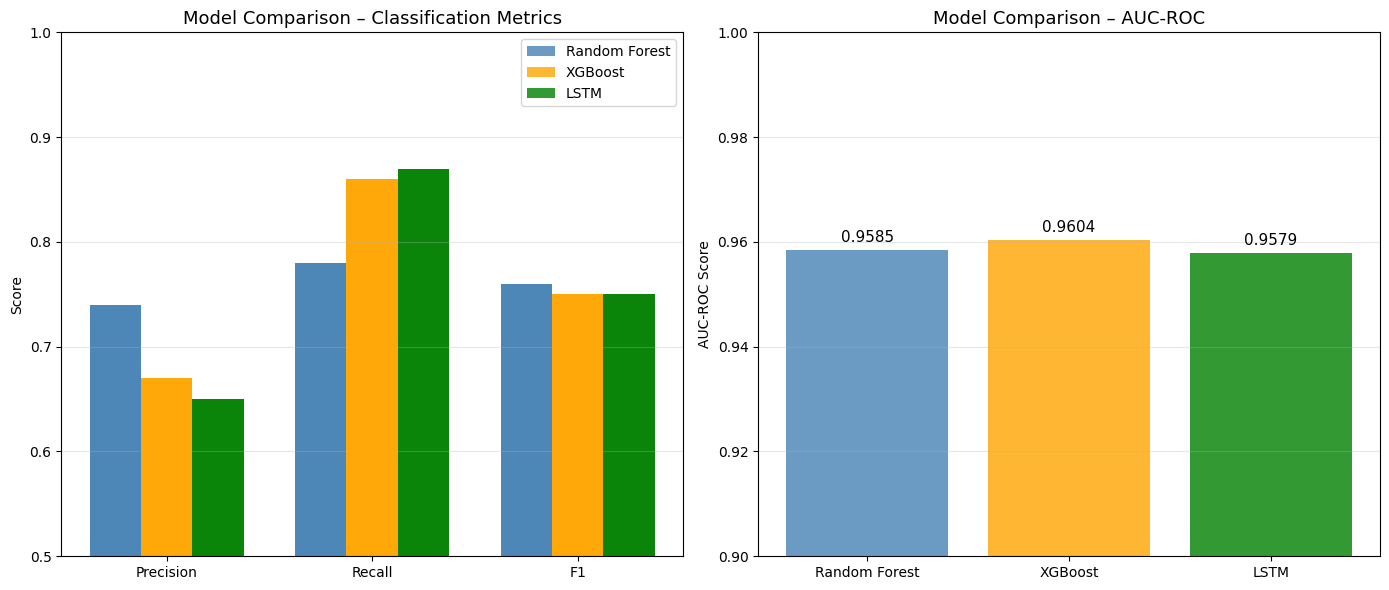

Plot saved!


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left – Precision, Recall, F1
metrics = ['Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'orange', 'green']

for i, (model, color) in enumerate(
        zip(df_results['Model'], colors)):
    values = df_results[df_results['Model'] == model][
        metrics].values.flatten()
    axes[0].bar(x + i*width, values, width,
                label=model, color=color, alpha=0.8)

axes[0].set_title('Model Comparison – Classification Metrics',
                   fontsize=13)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

for i, (model, color) in enumerate(
        zip(df_results['Model'], colors)):
    axes[0].bar(x + i*width,
                df_results[df_results['Model'] == model][
                    metrics].values.flatten(),
                width, color=color, alpha=0.8)

# Right – AUC-ROC comparison
auc_values = df_results['AUC_ROC'].values
bars = axes[1].bar(df_results['Model'], auc_values,
                    color=colors, alpha=0.8)
axes[1].set_title('Model Comparison – AUC-ROC', fontsize=13)
axes[1].set_ylabel('AUC-ROC Score')
axes[1].set_ylim(0.90, 1.0)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, auc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center',
                 va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('results/figures/model_comparison_metrics.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

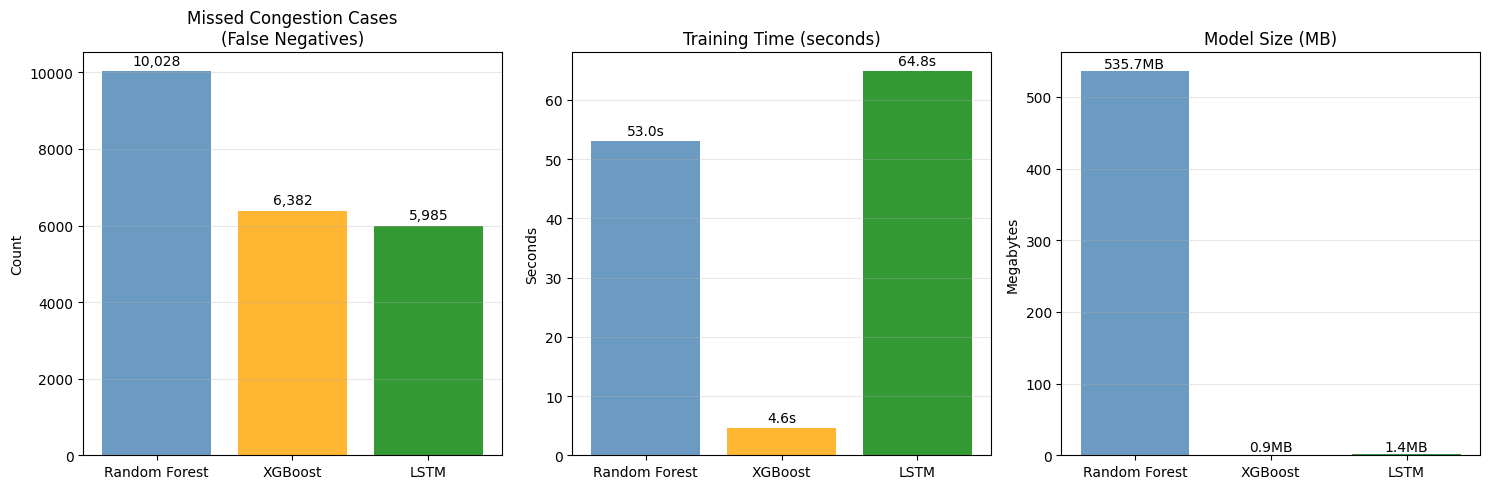

Plot saved!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# False negatives
bars = axes[0].bar(df_results['Model'],
                    df_results['False_Negatives'],
                    color=colors, alpha=0.8)
axes[0].set_title('Missed Congestion Cases\n(False Negatives)',
                   fontsize=12)
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, df_results['False_Negatives']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{val:,}', ha='center',
                 va='bottom', fontsize=10)

# Training time
bars2 = axes[1].bar(df_results['Model'],
                     df_results['Training_Time_s'],
                     color=colors, alpha=0.8)
axes[1].set_title('Training Time (seconds)', fontsize=12)
axes[1].set_ylabel('Seconds')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, df_results['Training_Time_s']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val}s', ha='center',
                 va='bottom', fontsize=10)

# Model size
bars3 = axes[2].bar(df_results['Model'],
                     df_results['Model_Size_MB'],
                     color=colors, alpha=0.8)
axes[2].set_title('Model Size (MB)', fontsize=12)
axes[2].set_ylabel('Megabytes')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, df_results['Model_Size_MB']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{val}MB', ha='center',
                 va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('results/figures/model_comparison_practical.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

c:\Users\abood\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


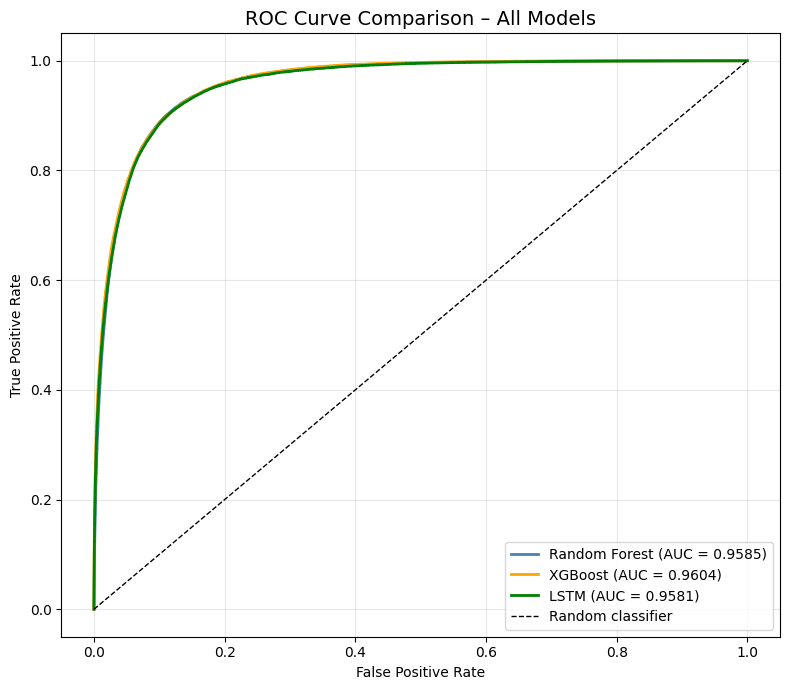

Plot saved!


In [5]:
# Load test data
X_test = pd.read_csv('data/processed/X_test.csv').values
y_test = pd.read_csv(
    'data/processed/y_test.csv').squeeze().values

# Load models
rf_model = joblib.load('models/random_forest_best.pkl')
xgb_model = joblib.load('models/xgboost_best.pkl')

import tensorflow as tf
from tensorflow.keras.models import load_model
lstm_model = load_model('models/lstm_best.keras')

# Reshape for LSTM
X_test_lstm = X_test.reshape(X_test.shape[0], 1, 
                               X_test.shape[1])

# Get probabilities
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
lstm_prob = lstm_model.predict(
    X_test_lstm, batch_size=1024, verbose=0).flatten()

# Plot ROC curves
fig, ax = plt.subplots(figsize=(8, 7))

for prob, name, color in zip(
    [rf_prob, xgb_prob, lstm_prob],
    ['Random Forest', 'XGBoost', 'LSTM'],
    ['steelblue', 'orange', 'green']):
    
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1,
        label='Random classifier')
ax.set_title('ROC Curve Comparison – All Models',
             fontsize=14)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/roc_curves_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

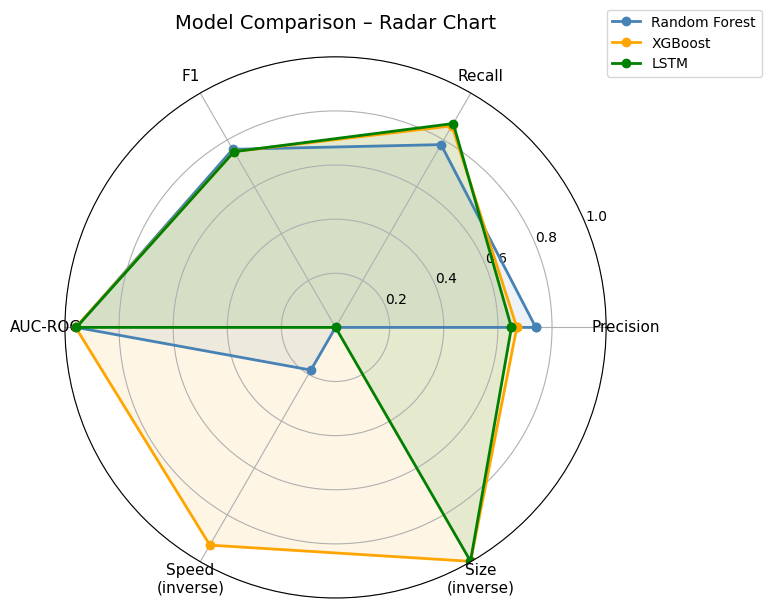

Plot saved!


In [6]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalize metrics for radar chart
categories = ['Precision', 'Recall', 'F1', 
              'AUC-ROC', 'Speed\n(inverse)', 
              'Size\n(inverse)']
N = len(categories)

# Normalize speed and size (inverse – higher is better)
max_time = max(df_results['Training_Time_s'])
max_size = max(df_results['Model_Size_MB'])

rf_values = [0.74, 0.78, 0.76, 0.9585,
             1 - 53/max_time,
             1 - 535.7/max_size]
xgb_values = [0.67, 0.86, 0.75, 0.9604,
              1 - 4.6/max_time,
              1 - 0.9/max_size]
lstm_values = [0.65, 0.87, 0.75, 0.9579,
               1 - 64.8/max_time,
               1 - 1.4/max_size]

angles = np.linspace(0, 2*np.pi, N,
                     endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8),
                        subplot_kw=dict(polar=True))

for values, color, label in zip(
    [rf_values, xgb_values, lstm_values],
    ['steelblue', 'orange', 'green'],
    ['Random Forest', 'XGBoost', 'LSTM']):
    
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=color, label=label)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison – Radar Chart',
             size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig('results/figures/radar_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [7]:
print("=" * 60)
print("        FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"\n{'Metric':<20} {'RF':>12} {'XGBoost':>12} "
      f"{'LSTM':>12}")
print("-" * 60)
metrics_display = [
    ('Precision',      0.74,   0.67,   0.65),
    ('Recall',         0.78,   0.86,   0.87),
    ('F1 Score',       0.76,   0.75,   0.75),
    ('AUC-ROC',        0.9585, 0.9604, 0.9579),
    ('False Negatives',10028,  6382,   5985),
    ('Training (s)',   53,     4.6,    64.8),
    ('Size (MB)',      535.7,  0.9,    1.4),
]

for name, rf, xgb, lstm in metrics_display:
    print(f"{name:<20} {rf:>12} {xgb:>12} {lstm:>12}")

print("=" * 60)
print("\n=== VERDICT ===")
print("""
For Early Warning System deployment:

BEST OVERALL:     XGBoost
Reason: Best balance of recall (0.86), minimal
        model size (0.9MB), fastest training (4.6s),
        well-calibrated probabilities.

BEST RECALL:      LSTM (0.87)
Reason: Catches most congestion cases.
        Preferred if false negatives are critical.

MOST BALANCED:    Random Forest
Reason: Highest precision (0.74) and F1 (0.76).
        Best if false alarms are a concern.

SELECTED FOR DASHBOARD: XGBoost
""")

        FINAL MODEL COMPARISON SUMMARY

Metric                         RF      XGBoost         LSTM
------------------------------------------------------------
Precision                    0.74         0.67         0.65
Recall                       0.78         0.86         0.87
F1 Score                     0.76         0.75         0.75
AUC-ROC                    0.9585       0.9604       0.9579
False Negatives             10028         6382         5985
Training (s)                   53          4.6         64.8
Size (MB)                   535.7          0.9          1.4

=== VERDICT ===

For Early Warning System deployment:

BEST OVERALL:     XGBoost
Reason: Best balance of recall (0.86), minimal
        model size (0.9MB), fastest training (4.6s),
        well-calibrated probabilities.

BEST RECALL:      LSTM (0.87)
Reason: Catches most congestion cases.
        Preferred if false negatives are critical.

MOST BALANCED:    Random Forest
Reason: Highest precision (0.74) and F1 (0.7